# KAN-NNUE Training in Bullet

Train KAN (B-spline) and baseline (SCReLU) NNUE networks on the same data,
then compare loss curves.

**Runtime**: Use a GPU runtime (T4 or better). Go to Runtime > Change runtime type > GPU.

Architecture:
- **KAN**: `768 -> ft(128) -> KAN(256->128) -> KAN(128->1) -> sigmoid`
- **Baseline**: `768 -> ft(128) -> SCReLU -> 256->128 -> SCReLU -> 128->1 -> sigmoid`

## 1. Setup: Install Rust & Clone Repo

In [1]:
%%bash
# Install Rust (if not already installed)
if ! command -v cargo &> /dev/null; then
    curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh -s -- -y
    echo 'source $HOME/.cargo/env' >> ~/.bashrc
fi
source $HOME/.cargo/env
rustc --version
cargo --version


  stable-x86_64-unknown-linux-gnu installed - rustc 1.94.1 (e408947bf 2026-03-25)


Rust is installed now. Great!

To get started you may need to restart your current shell.
This would reload your PATH environment variable to include
Cargo's bin directory ($HOME/.cargo/bin).

To configure your current shell, you need to source
the corresponding env file under $HOME/.cargo.

This is usually done by running one of the following (note the leading DOT):
. "$HOME/.cargo/env"            # For sh/bash/zsh/ash/dash/pdksh
source "$HOME/.cargo/env.fish"  # For fish
source "~/.cargo/env.nu"  # For nushell
source "$HOME/.cargo/env.tcsh"  # For tcsh
. "$HOME/.cargo/env.ps1"        # For pwsh
source "$HOME/.cargo/env.xsh"   # For xonsh
rustc 1.94.1 (e408947bf 2026-03-25)
cargo 1.94.1 (29ea6fb6a 2026-03-24)


info: downloading installer
warn: It looks like you have an existing rustup settings file at:
warn: /root/.rustup/settings.toml
warn: Rustup will install the default toolchain as specified in the settings file,
warn: instead of the one inferred from the default host triple.
info: profile set to default
info: default host triple is x86_64-unknown-linux-gnu
info: syncing channel updates for stable-x86_64-unknown-linux-gnu
info: latest update on 2026-03-26 for version 1.94.1 (e408947bf 2026-03-25)
info: downloading 6 components
info: default toolchain set to stable-x86_64-unknown-linux-gnu


In [2]:
%%bash
source $HOME/.cargo/env

# Clone the bullet fork with KAN support
if [ ! -d /content/bullet ]; then
    git clone https://github.com/y0sif/bullet.git /content/bullet
fi
cd /content/bullet
git pull origin main
git log --oneline -5

Already up to date.
f8044c0 LUT v2: cache-friendly [in][sample][out] layout, 64 samples, i8 quantization
5a13f31 Phase 3: LUT-KAN quantization and export via SavedFormat
25fcb6c Fix fused kernel: use cuBLAS for matmuls, only fuse basis+SiLU
ba9dd15 Phase 2: FusedKanLayer — fused CUDA kernel for KAN layers
c36049d Switch both examples to CReLU to match kanue's exact setup


Cloning into '/content/bullet'...
From https://github.com/y0sif/bullet
 * branch            main       -> FETCH_HEAD


## 2. Download Training Data

In [3]:
%%bash
apt-get install -y zstd 2>/dev/null || true

mkdir -p /content/bullet/data
cd /content/bullet/data

if [ ! -f test77.binpack ]; then
    echo "Downloading test77 binpack from HuggingFace (~1.3 GB compressed)..."
    wget -q -O test77.binpack.zst \
        "https://huggingface.co/datasets/linrock/test77/resolve/main/test77-2022-01-jan-2tb7p.binpack.zst"
    echo "Download complete. Decompressing..."
    zstd -d test77.binpack.zst -o test77.binpack --rm
    echo "Done!"
fi

ls -lh test77.binpack

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 1s (1,006 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
Download complete. Decompressing...
Done!
-rw-r--r-- 1 root root 2.7G Apr 15 12:19 test77.binpack


test77.binpack.zst  : 2895291738 bytes                                         


## 3. Build Both Examples

In [4]:
%%bash
source $HOME/.cargo/env
cd /content/bullet

# Check CUDA availability
nvidia-smi || echo "WARNING: No GPU detected. Training will be very slow."
echo "---"
nvcc --version || echo "WARNING: nvcc not found. Will try CPU fallback."

Wed Apr 15 12:20:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
%%bash
source $HOME/.cargo/env
cd /content/bullet

# Build both examples in release mode
# Uses default features (cuda) if nvcc is available, falls back to cpu
if command -v nvcc &> /dev/null; then
    echo "Building with CUDA support..."
    cargo build --release --example kan_simple --example kan_baseline 2>&1
else
    echo "Building with CPU only (no CUDA toolkit found)..."
    cargo build --no-default-features --features cpu --release --example kan_simple --example kan_baseline 2>&1
fi
echo "Build complete!"

Building with CUDA support...
    Updating crates.io index
  Downloaded bulletformat v1.8.0
  Downloaded cfg-if v1.0.0
  Downloaded autocfg v1.2.0
  Downloaded atty v0.2.14
  Downloaded bitflags v1.3.2
  Downloaded arrayvec v0.7.6
  Downloaded serde_spanned v0.6.8
  Downloaded version_check v0.9.4
  Downloaded toml_datetime v0.6.8
  Downloaded lazy_static v1.4.0
  Downloaded vec_map v0.8.2
  Downloaded scopeguard v1.2.0
  Downloaded structopt-derive v0.4.18
  Downloaded rand_chacha v0.9.0
  Downloaded unicode-width v0.1.11
  Downloaded toml v0.8.20
  Downloaded structopt v0.3.26
  Downloaded serde v1.0.218
  Downloaded toml_edit v0.22.24
  Downloaded unicode-segmentation v1.11.0
  Downloaded libm v0.2.8
  Downloaded hashbrown v0.15.2
  Downloaded winnow v0.7.3
  Downloaded rand v0.9.0
  Downloaded memchr v2.7.4
  Downloaded syn v1.0.109
  Downloaded zerocopy v0.8.21
  Downloaded clap v2.34.0
  Downloaded indexmap v2.7.1
  Downloaded rand_distr v0.5.1
  Downloaded syn v2.0.98
  Download

## 4. Train Baseline (SCReLU)

In [6]:
import subprocess, sys, os
os.environ["PATH"] = os.path.expanduser("~/.cargo/bin") + ":" + os.environ["PATH"]

cmd = ["cargo", "run", "--release", "--example", "kan_baseline"]
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, cwd="/content/bullet", text=True, bufsize=1)
log = open("/content/baseline_log.txt", "w")
for line in proc.stdout:
    sys.stdout.write(line)
    sys.stdout.flush()
    log.write(line)
log.close()
proc.wait()
print(f"\nExited with code {proc.returncode}")

   --> crates/bullet_cuda_backend/src/ops/kan.rs:256:13
    |
256 |         let out_features = self.spline_weight.shape.rows();
    |             ^^^^^^^^^^^^ help: if this is intentional, prefix it with an underscore: `_out_features`
    |
    = note: `#[warn(unused_variables)]` (part of `#[warn(unused)]`) on by default

    Finished `release` profile [optimized] target(s) in 0.05s
     Running `target/release/examples/kan_baseline`
Training Preamble
Net Name               : kan-baseline
Batch Size             : 16384
Batches / Superbatch   : 488
Positions / Superbatch : 7995392
Start Superbatch       : 1
End Superbatch         : 40
Eval Scale             : 400
Save Rate              : 10
WDL Scheduler          : constant 0.75
LR Scheduler           : start 0.001 gamma 0.1 drop every 18 superbatches
Threads                : 4
Output Path            : checkpoints
Beginning Training
superbatch 1 [0.0% (0/488 batches, 46855 pos/sec)]
Estimated time to end of superbatch: infs     superbat

## 5. Train KAN

In [7]:
import subprocess, sys, os
os.environ["PATH"] = os.path.expanduser("~/.cargo/bin") + ":" + os.environ["PATH"]

cmd = ["cargo", "run", "--release", "--example", "kan_simple"]
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, cwd="/content/bullet", text=True, bufsize=1)
log = open("/content/kan_log.txt", "w")
for line in proc.stdout:
    sys.stdout.write(line)
    sys.stdout.flush()
    log.write(line)
log.close()
proc.wait()
print(f"\nExited with code {proc.returncode}")

   --> crates/bullet_cuda_backend/src/ops/kan.rs:256:13
    |
256 |         let out_features = self.spline_weight.shape.rows();
    |             ^^^^^^^^^^^^ help: if this is intentional, prefix it with an underscore: `_out_features`
    |
    = note: `#[warn(unused_variables)]` (part of `#[warn(unused)]`) on by default

    Finished `release` profile [optimized] target(s) in 0.10s
     Running `target/release/examples/kan_simple`
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Flow                      | Type         | Operation                                                                                                                |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| %0                        | 12x1         | __unknown      

## 6. Compare Loss Curves

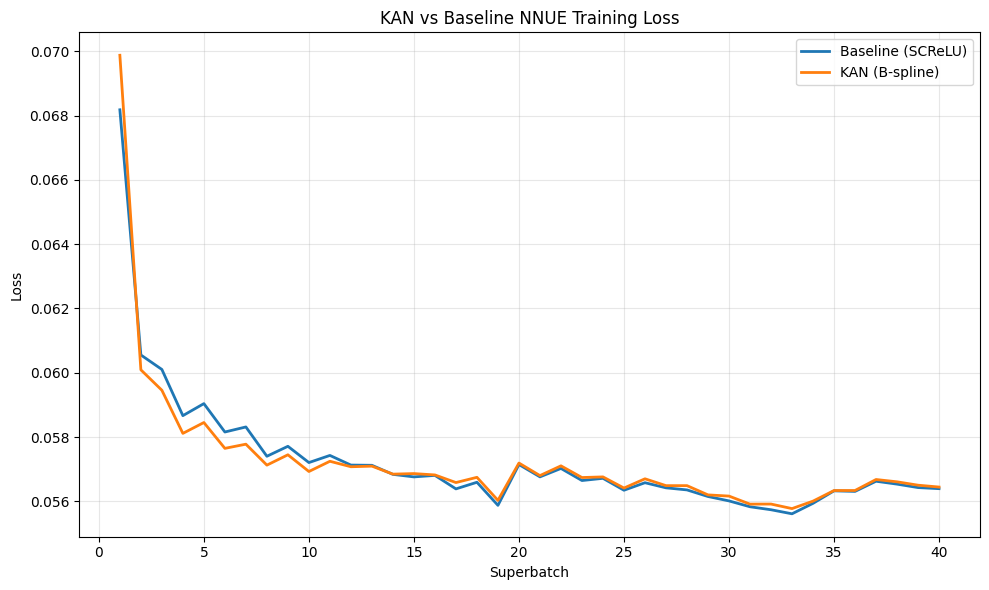


Baseline final loss: 0.056393
KAN final loss:      0.056443
Improvement:         -0.1%


In [8]:
import re
import matplotlib.pyplot as plt

def strip_ansi(s):
    """Remove ANSI escape codes from string."""
    return re.sub(r'\x1b\[[0-9;]*m', '', s)

def parse_bullet_log(path):
    """Parse Bullet training log to extract superbatch loss values."""
    losses = []
    with open(path) as f:
        for line in f:
            clean = strip_ansi(line)
            # Bullet format: "superbatch N | time Ts | running loss X.XXXXXX | ..."
            m = re.search(r'superbatch\s+(\d+)\s+\|.*?running loss\s+([\d.]+)', clean)
            if m:
                losses.append((int(m.group(1)), float(m.group(2))))
    return losses

baseline = parse_bullet_log('/content/baseline_log.txt')
kan = parse_bullet_log('/content/kan_log.txt')

if baseline and kan:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot([x[0] for x in baseline], [x[1] for x in baseline], label='Baseline (SCReLU)', linewidth=2)
    ax.plot([x[0] for x in kan], [x[1] for x in kan], label='KAN (B-spline)', linewidth=2)
    ax.set_xlabel('Superbatch')
    ax.set_ylabel('Loss')
    ax.set_title('KAN vs Baseline NNUE Training Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/kan_vs_baseline.png', dpi=150)
    plt.show()

    baseline_final = baseline[-1][1]
    kan_final = kan[-1][1]
    improvement = (baseline_final - kan_final) / baseline_final * 100
    print(f'\nBaseline final loss: {baseline_final:.6f}')
    print(f'KAN final loss:      {kan_final:.6f}')
    print(f'Improvement:         {improvement:+.1f}%')
else:
    print('Could not parse training logs.')
    if not baseline:
        print('  - baseline_log.txt: no superbatch loss lines found')
        with open('/content/baseline_log.txt') as f:
            print('  First 5 lines:', [strip_ansi(l.strip()) for l in f.readlines()[:5]])
    if not kan:
        print('  - kan_log.txt: no superbatch loss lines found')
        with open('/content/kan_log.txt') as f:
            print('  First 5 lines:', [strip_ansi(l.strip()) for l in f.readlines()[:5]])

## 7. Save Results

Checkpoints are saved to `/content/bullet/checkpoints/`. Copy to Drive if needed:

In [9]:
import shutil, os
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

DRIVE_BASE = Path('/content/drive/MyDrive/kanue-bullet')
DRIVE_BASE.mkdir(parents=True, exist_ok=True)

for src in ['/content/kan_log.txt', '/content/baseline_log.txt', '/content/kan_vs_baseline.png']:
    if os.path.exists(src):
        shutil.copy2(src, DRIVE_BASE / os.path.basename(src))
        print(f'Copied {src}')
    else:
        print(f'Skipped {src} (not found)')

# Copy checkpoints if they exist
ckpt_dir = Path('/content/bullet/checkpoints')
if ckpt_dir.exists():
    dest = DRIVE_BASE / 'checkpoints'
    if dest.exists():
        shutil.rmtree(dest)
    shutil.copytree(ckpt_dir, dest)
    print(f'Copied checkpoints -> {dest}')

Mounted at /content/drive
Copied /content/kan_log.txt
Copied /content/baseline_log.txt
Copied /content/kan_vs_baseline.png
Copied checkpoints -> /content/drive/MyDrive/kanue-bullet/checkpoints


## 8. Phase A — Variant Sweep

Train 5 KAN variants sequentially, compare training loss.

- **A**: B-spline + SiLU base (control)
- **B**: B-spline + SCReLU base
- **C**: B-spline, no base path (pure spline)
- **D**: B-spline + linear base
- **E**: ReLU-KAN (pure basis, arXiv 2406.02075)

All variants run UNFUSED (the `FuseKanLayer` pass is disabled during Phase A because it
pattern-matches SiLU + BSplineBasis specifically). Expect ~1.7x slower per superbatch
vs fused; 40 superbatches on T4 = ~10 min per variant.

In [ ]:
%%bash
source $HOME/.cargo/env
cd /content/bullet
# Build all 5 variants release mode
for v in a b c d e; do
    echo "=== Building kan_variant_${v} ==="
    cargo build --release --example kan_variant_${v} 2>&1 | tail -5
done

In [ ]:
import subprocess, sys, os
os.environ["PATH"] = os.path.expanduser("~/.cargo/bin") + ":" + os.environ["PATH"]

VARIANTS = ["a", "b", "c", "d", "e"]
for v in VARIANTS:
    log_path = f"/content/variant_{v}_log.txt"
    print(f"\n{'='*60}\n Training kan_variant_{v} -> {log_path}\n{'='*60}")
    cmd = ["cargo", "run", "--release", "--example", f"kan_variant_{v}"]
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            cwd="/content/bullet", text=True, bufsize=1)
    with open(log_path, "w") as log:
        for line in proc.stdout:
            sys.stdout.write(line); sys.stdout.flush()
            log.write(line)
    proc.wait()
    print(f"Variant {v} exit code: {proc.returncode}")

In [ ]:
import re
import matplotlib.pyplot as plt

def strip_ansi(s):
    return re.sub(r'\x1b\[[0-9;]*m', '', s)

def parse_bullet_log(path):
    losses = []
    with open(path) as f:
        for line in f:
            m = re.search(r'superbatch\s+(\d+)\s+\|.*?running loss\s+([\d.]+)', strip_ansi(line))
            if m:
                losses.append((int(m.group(1)), float(m.group(2))))
    return losses

VARIANT_LABELS = {
    "a": "A: B-spline + SiLU (control)",
    "b": "B: B-spline + SCReLU",
    "c": "C: B-spline (no base)",
    "d": "D: B-spline + linear",
    "e": "E: ReLU-KAN",
}

all_losses = {}
for v in ["a", "b", "c", "d", "e"]:
    losses = parse_bullet_log(f"/content/variant_{v}_log.txt")
    if losses:
        all_losses[v] = losses

if all_losses:
    fig, ax = plt.subplots(figsize=(11, 7))
    for v, losses in all_losses.items():
        ax.plot([x[0] for x in losses], [x[1] for x in losses],
                label=VARIANT_LABELS[v], linewidth=2)
    ax.set_xlabel("Superbatch")
    ax.set_ylabel("Running loss")
    ax.set_title("Phase A KAN Variant Sweep")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("/content/kan_variant_sweep.png", dpi=150)
    plt.show()

    print("\nFinal loss per variant:")
    ranked = sorted(all_losses.items(), key=lambda kv: kv[1][-1][1])
    for v, losses in ranked:
        print(f"  {VARIANT_LABELS[v]:<38}  {losses[-1][1]:.6f}")
else:
    print("No variant logs parsed. Check /content/variant_*_log.txt.")